# Simple Scheduling Algorithm using QAOA



N tasks    \
M workers  \
M <= N     

Assign tasks to workers    \
Each task assigned only to one worker

input  - Weight matrix, W \
output - optimized scheuling of tasks to workers resulting a least cost \
                      \
W(i, j) indicate the cost of jth task assigned to ith worker



### QAOA procedure for Simple Scheduling

1. Weight matrix to QUBO Cost

2. QUBO Cost to Hamiltonian

3. QAOA Circuit
    * QAOA Ansatz
    * Transpile to Aer Simulator circuit

4. Optimization
    * Estimator for evaluating Energy or Cost
    * Classical parameter optimization through minimize function

5. Results
    * Generate Sampler output of the circuit assigned with best parameters
    * Optimal Scheduling
    * Visualization



In [894]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: c:\Users\kcrav\miniconda3\envs\myenv\python.exe
Python version: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


In [895]:
!jupyter kernelspec list

Available kernels:
  python3    C:\Users\kcrav\miniconda3\envs\myenv\share\jupyter\kernels\python3
  myenv      C:\Users\kcrav\AppData\Roaming\jupyter\kernels\myenv


In [896]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

from scipy.optimize import minimize

## Weight matrix to QUBO Cost




In [897]:
N = 3
M = 2
p_reps = 2

init_param_values = []

if p_reps == 4:
    init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi*1.3, np.pi / 6, np.pi*1.6, np.pi / 5, np.pi*1.2]
elif p_reps == 3:
    init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi*1.3, np.pi / 5, np.pi*1.2]
elif p_reps == 2:
    init_param_values = [np.pi / 3, np.pi / 4, np.pi / 5, np.pi*1.2]
elif p_reps == 1:
    init_param_values = [np.pi / 3, np.pi / 6]

assert N > 0 and M > 0, "N and M must be positive integers."
#assert N >= M, "N must be greater than or equal to M for a valid scheduling problem."

def generate_weight_matrix(M, N):
    w = np.random.randint(1, 8, size=(M, N))
    return w

w = generate_weight_matrix(M, N)
print('w:', w)

w_col = w.reshape(-1, 1)


w: [[1 5 2]
 [7 3 1]]


In [898]:
'''
L = 10*int(np.ceil(sum(w_col.flatten())/N))  # sum of all MxN weights divided by N, ceiled to the nearest integer. Since Sigma(i=1 to M) Sigma(j=1 to N) x_ij = N, so divide by N
Q = np.zeros((M * N, M * N))  # initialize Q as a lower triangular matrix of ones
for i in range(M * N):
    for j in range(int(np.floor(i/M)*M),i):
        Q[i, j] = 2*L
C = 0.00001*w_col - L*np.ones((M * N, 1))

#print(np.diag(Q))
#print(np.diag(np.diag(Q)))
#Q = Q - np.diag(np.diag(Q))  # set diagonal elements to zero

print('Q:', Q)
print('C:', C)
'''

"\nL = 10*int(np.ceil(sum(w_col.flatten())/N))  # sum of all MxN weights divided by N, ceiled to the nearest integer. Since Sigma(i=1 to M) Sigma(j=1 to N) x_ij = N, so divide by N\nQ = np.zeros((M * N, M * N))  # initialize Q as a lower triangular matrix of ones\nfor i in range(M * N):\n    for j in range(int(np.floor(i/M)*M),i):\n        Q[i, j] = 2*L\nC = 0.00001*w_col - L*np.ones((M * N, 1))\n\n#print(np.diag(Q))\n#print(np.diag(np.diag(Q)))\n#Q = Q - np.diag(np.diag(Q))  # set diagonal elements to zero\n\nprint('Q:', Q)\nprint('C:', C)\n"

In [899]:
L = 1*int(np.ceil(sum(w_col.flatten())/N))  # sum of all MxN weights divided by N, ceiled to the nearest integer. Since Sigma(i=1 to M) Sigma(j=1 to N) x_ij = N, so divide by N
Q = np.zeros((M * N, M * N))  # initialize Q as a lower triangular matrix of ones
for j in range(N):
    for i in range(M):
        for l in range(i):
            Q[i * N + j, l * N + j] = 2*L
C = 1*w_col - L*np.ones((M * N, 1))

#print(np.diag(Q))
#print(np.diag(np.diag(Q)))
#Q = Q - np.diag(np.diag(Q))  # set diagonal elements to zero

print('Q:', Q)
print('C:', C)

Q: [[ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [14.  0.  0.  0.  0.  0.]
 [ 0. 14.  0.  0.  0.  0.]
 [ 0.  0. 14.  0.  0.  0.]]
C: [[-6.]
 [-2.]
 [-5.]
 [ 0.]
 [-4.]
 [-6.]]


In [900]:
def qubo_cost_function(x, Q, C):
    return 0.5 * x.T @ Q @ x + C.T @ x

# brute-force search for CLASSICAL optimal solution
min_cost = 100000
min_bitstring = None
max_cost = -100000
max_bitstring = None
for i in range(2**(M*N)):
    x = np.array(list(np.binary_repr(i, width=M*N)), dtype=int)
    cost = qubo_cost_function(x, Q, C)
    #print(f"x: {x}, cost: {cost}")
    print(f"x: {x}, x.T @ Q @ x: {x.T @ Q @ x}, C.T @ x: {C.T @ x}")
    if cost < min_cost:
        min_cost = cost
        min_bitstring = x
    if cost > max_cost:
        max_cost = cost
        max_bitstring = x

#print(f"Maximum cost: {max_cost}, achieved by bitstring: {max_bitstring}, \n reshaped bitstring: \n {max_bitstring.reshape(M, N)}")
print(f"Minimum cost: {min_cost}, achieved by bitstring: {min_bitstring}, \n reshaped bitstring: \n {min_bitstring.reshape(M, N)}")
print('w:', w)
print('w_col:', w_col)

x: [0 0 0 0 0 0], x.T @ Q @ x: 0.0, C.T @ x: [0.]
x: [0 0 0 0 0 1], x.T @ Q @ x: 0.0, C.T @ x: [-6.]
x: [0 0 0 0 1 0], x.T @ Q @ x: 0.0, C.T @ x: [-4.]
x: [0 0 0 0 1 1], x.T @ Q @ x: 0.0, C.T @ x: [-10.]
x: [0 0 0 1 0 0], x.T @ Q @ x: 0.0, C.T @ x: [0.]
x: [0 0 0 1 0 1], x.T @ Q @ x: 0.0, C.T @ x: [-6.]
x: [0 0 0 1 1 0], x.T @ Q @ x: 0.0, C.T @ x: [-4.]
x: [0 0 0 1 1 1], x.T @ Q @ x: 0.0, C.T @ x: [-10.]
x: [0 0 1 0 0 0], x.T @ Q @ x: 0.0, C.T @ x: [-5.]
x: [0 0 1 0 0 1], x.T @ Q @ x: 14.0, C.T @ x: [-11.]
x: [0 0 1 0 1 0], x.T @ Q @ x: 0.0, C.T @ x: [-9.]
x: [0 0 1 0 1 1], x.T @ Q @ x: 14.0, C.T @ x: [-15.]
x: [0 0 1 1 0 0], x.T @ Q @ x: 0.0, C.T @ x: [-5.]
x: [0 0 1 1 0 1], x.T @ Q @ x: 14.0, C.T @ x: [-11.]
x: [0 0 1 1 1 0], x.T @ Q @ x: 0.0, C.T @ x: [-9.]
x: [0 0 1 1 1 1], x.T @ Q @ x: 14.0, C.T @ x: [-15.]
x: [0 1 0 0 0 0], x.T @ Q @ x: 0.0, C.T @ x: [-2.]
x: [0 1 0 0 0 1], x.T @ Q @ x: 0.0, C.T @ x: [-8.]
x: [0 1 0 0 1 0], x.T @ Q @ x: 14.0, C.T @ x: [-6.]
x: [0 1 0 0 1 1], x.T 

In [867]:
x = np.array(min_bitstring, dtype=float)

print(x.T @ Q @ x, C.T @ x)

x, Q, C

0.0 [-262.]


(array([0., 0., 0., 1., 1., 1.]),
 array([[  0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.],
        [180.,   0.,   0.,   0.,   0.,   0.],
        [  0., 180.,   0.,   0.,   0.,   0.],
        [  0.,   0., 180.,   0.,   0.,   0.]]),
 array([[-85.],
        [-83.],
        [-84.],
        [-87.],
        [-89.],
        [-86.]]))

In [778]:
a = np.array([[0, 1, 0, 1, 1, 0]])
print(a.reshape(2, 3))
print('w_col:', w_col)
print('w_col:', w_col.reshape(2, 3))

[[0 1 0]
 [1 1 0]]
w_col: [[5]
 [7]
 [4]
 [1]
 [6]
 [7]]
w_col: [[5 7 4]
 [1 6 7]]


## QUBO Cost to Hamiltonian




In [598]:
def classical_qubo_to_hamiltonian(Q, C):
    n = len(C)
    pauli_list = []
    
    for i in range(n):
        if C[i] != 0:
            pauli_list.append(('Z', [i], -np.float64(np.sum(Q[i,:])/2 +C[i][0]/2)))
    
    for i in range(n):
        for j in range(i):
            if Q[i, j] != 0:
                pauli_list.append(('ZZ', [i, j], np.float64(Q[i, j]/4)))
                pass
    
    return pauli_list

In [599]:
pauli_list = classical_qubo_to_hamiltonian(Q, C)
no_of_qubits = M * N
Cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=no_of_qubits)
Cost_hamiltonian

SparsePauliOp(['IIIIIZ', 'IIIIZI', 'IIIZII', 'IIZIII', 'IZIIII', 'ZIIIII', 'IIIIZZ', 'IIIZIZ', 'IIIZZI', 'IIZIIZ', 'IIZIZI', 'IIZZII', 'IZIIIZ', 'IZIIZI', 'IZIZII', 'IZZIII', 'ZIIIIZ', 'ZIIIZI', 'ZIIZII', 'ZIZIII', 'ZZIIII'],
              coeffs=[  498. +0.j,  -503.5+0.j, -1500.5+0.j, -2502.5+0.j, -3503. +0.j,
 -4503. +0.j,   500. +0.j,   500. +0.j,   500. +0.j,   500. +0.j,
   500. +0.j,   500. +0.j,   500. +0.j,   500. +0.j,   500. +0.j,
   500. +0.j,   500. +0.j,   500. +0.j,   500. +0.j,   500. +0.j,
   500. +0.j])


## QAOA Circuit

### QAOA Ansatz


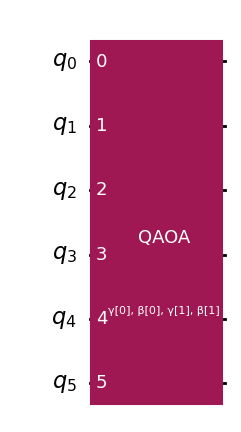

In [600]:
circuit = QAOAAnsatz(cost_operator=Cost_hamiltonian, reps=p_reps)
#circuit.measure_all()

circuit.draw("mpl")

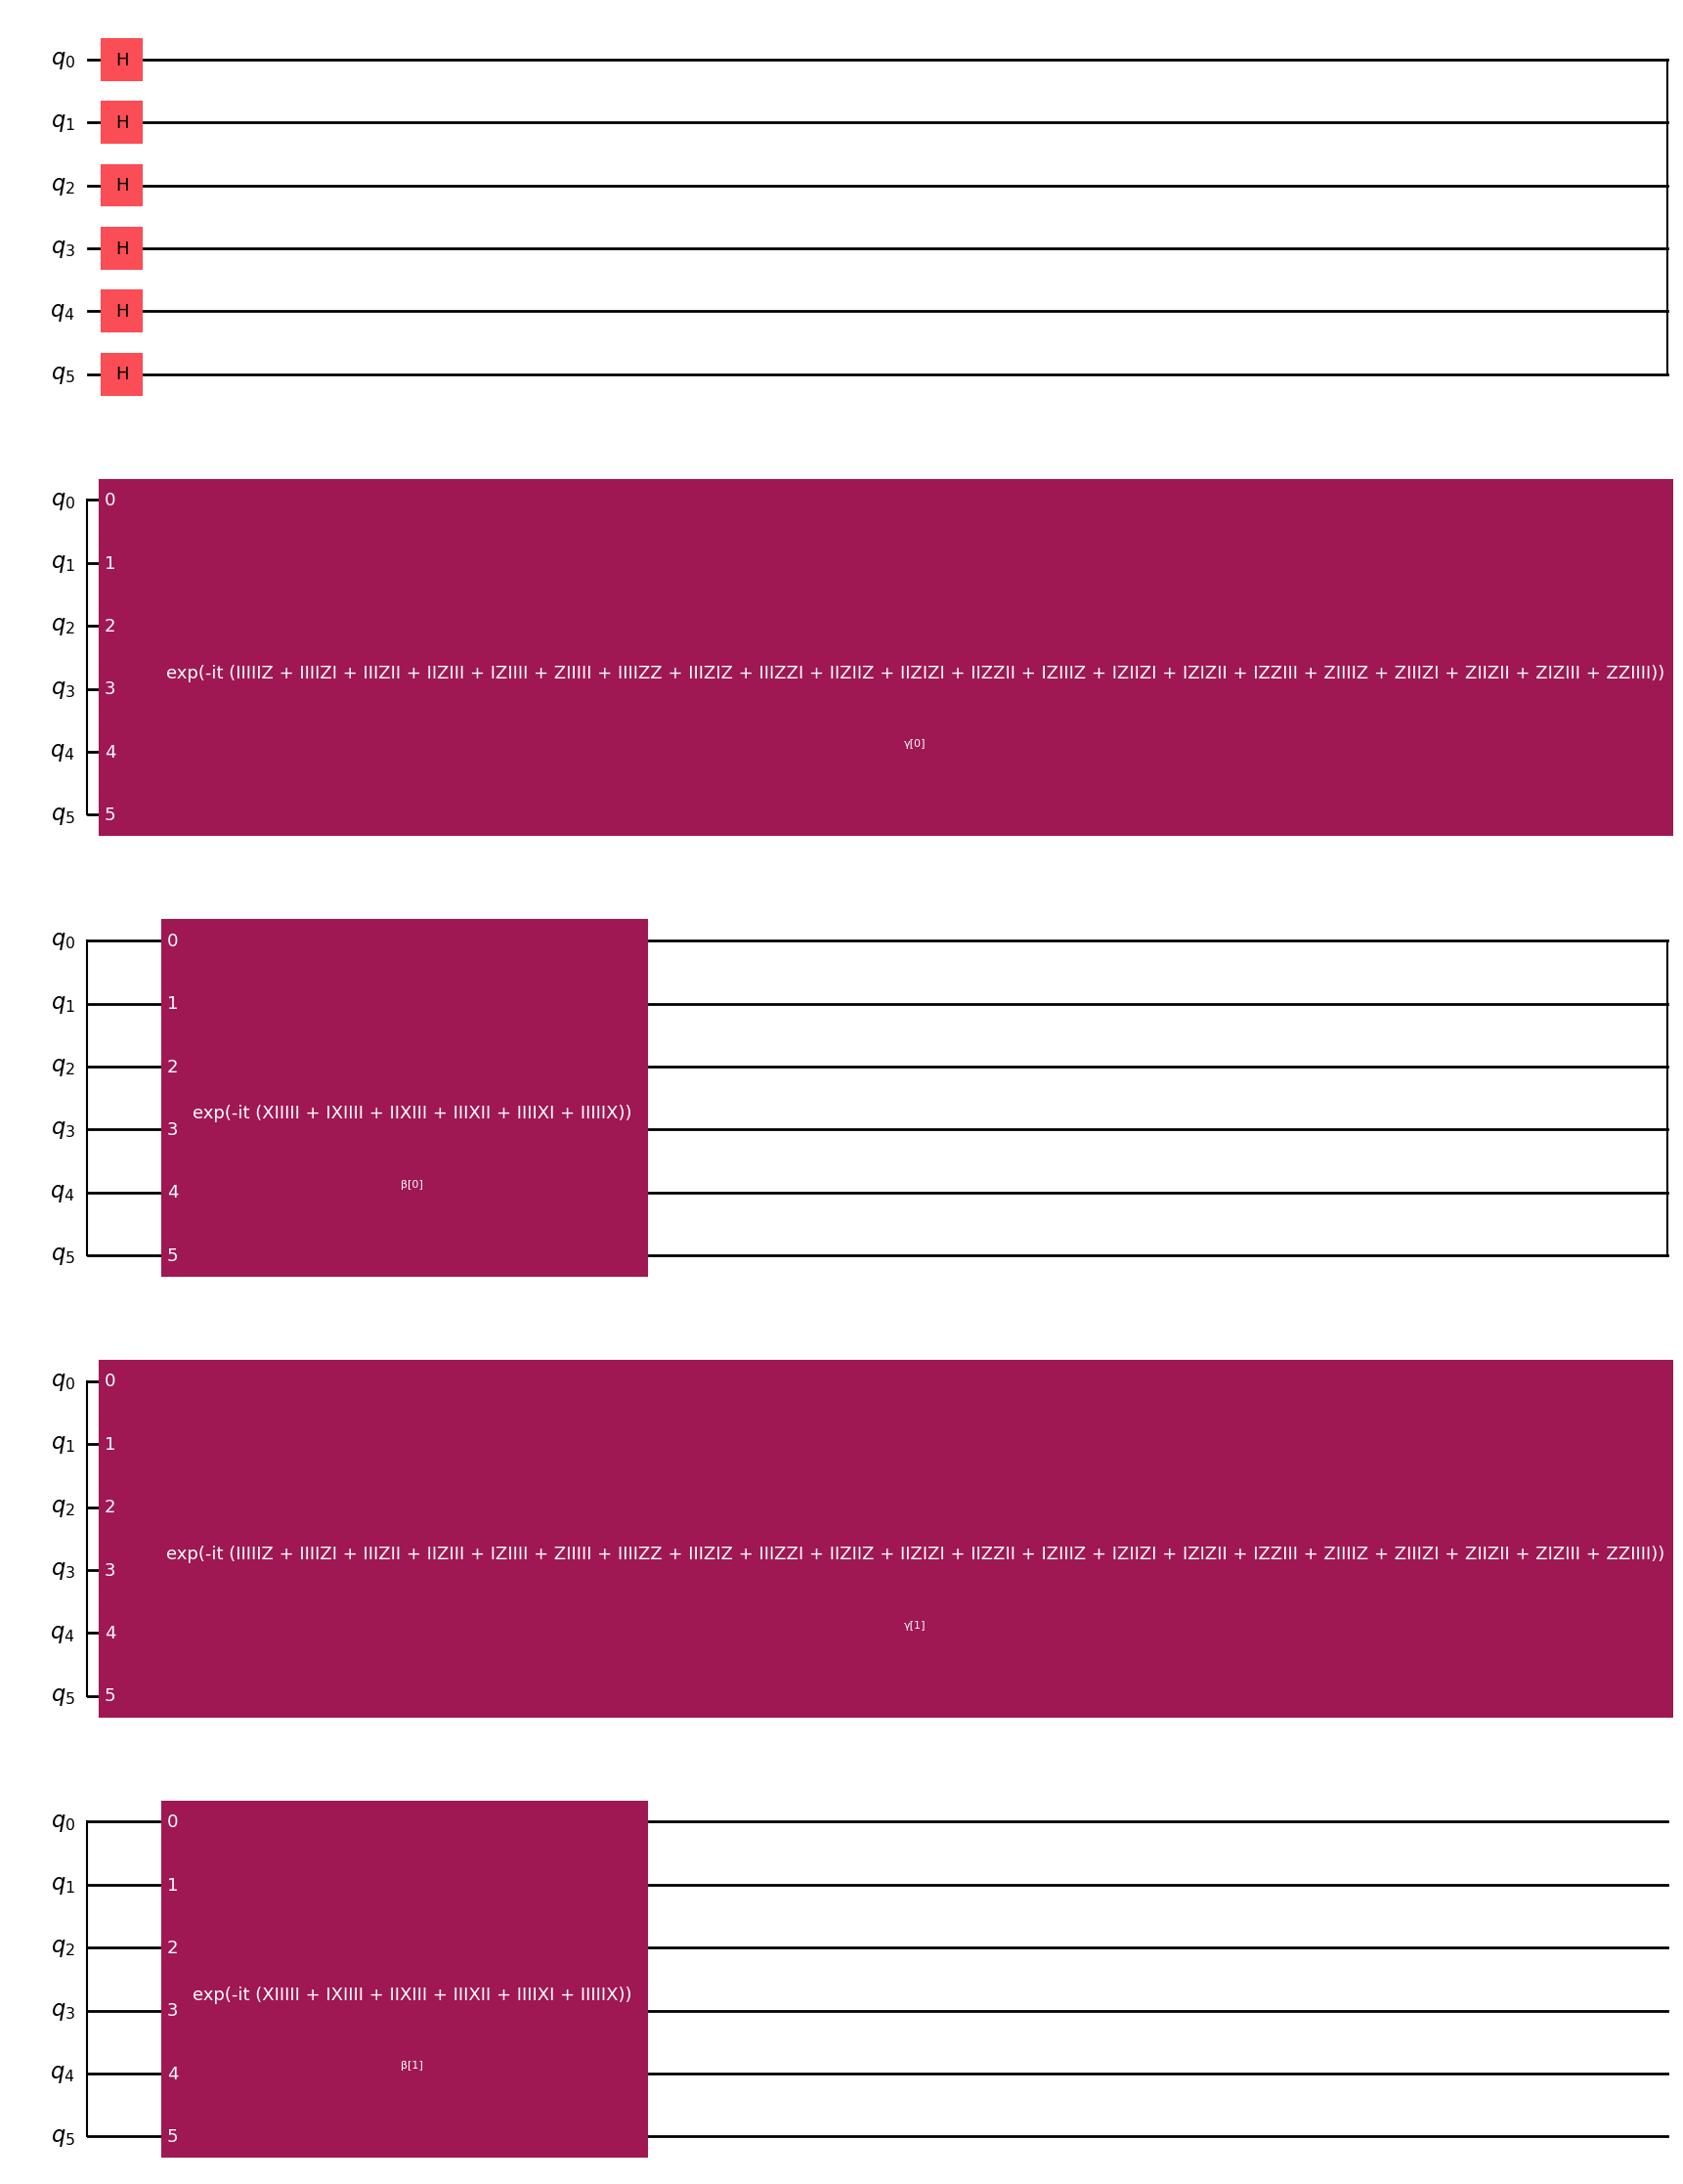

In [601]:
circuit.decompose().draw("mpl")


### Transpile to Aer Simulator circuit


In [602]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

In [603]:
binding_dict = {param: value for param, value in zip(circuit.parameters, init_param_values)}
bound_circuit = circuit.assign_parameters(binding_dict)
bound_circuit.parameters

ParameterView([])

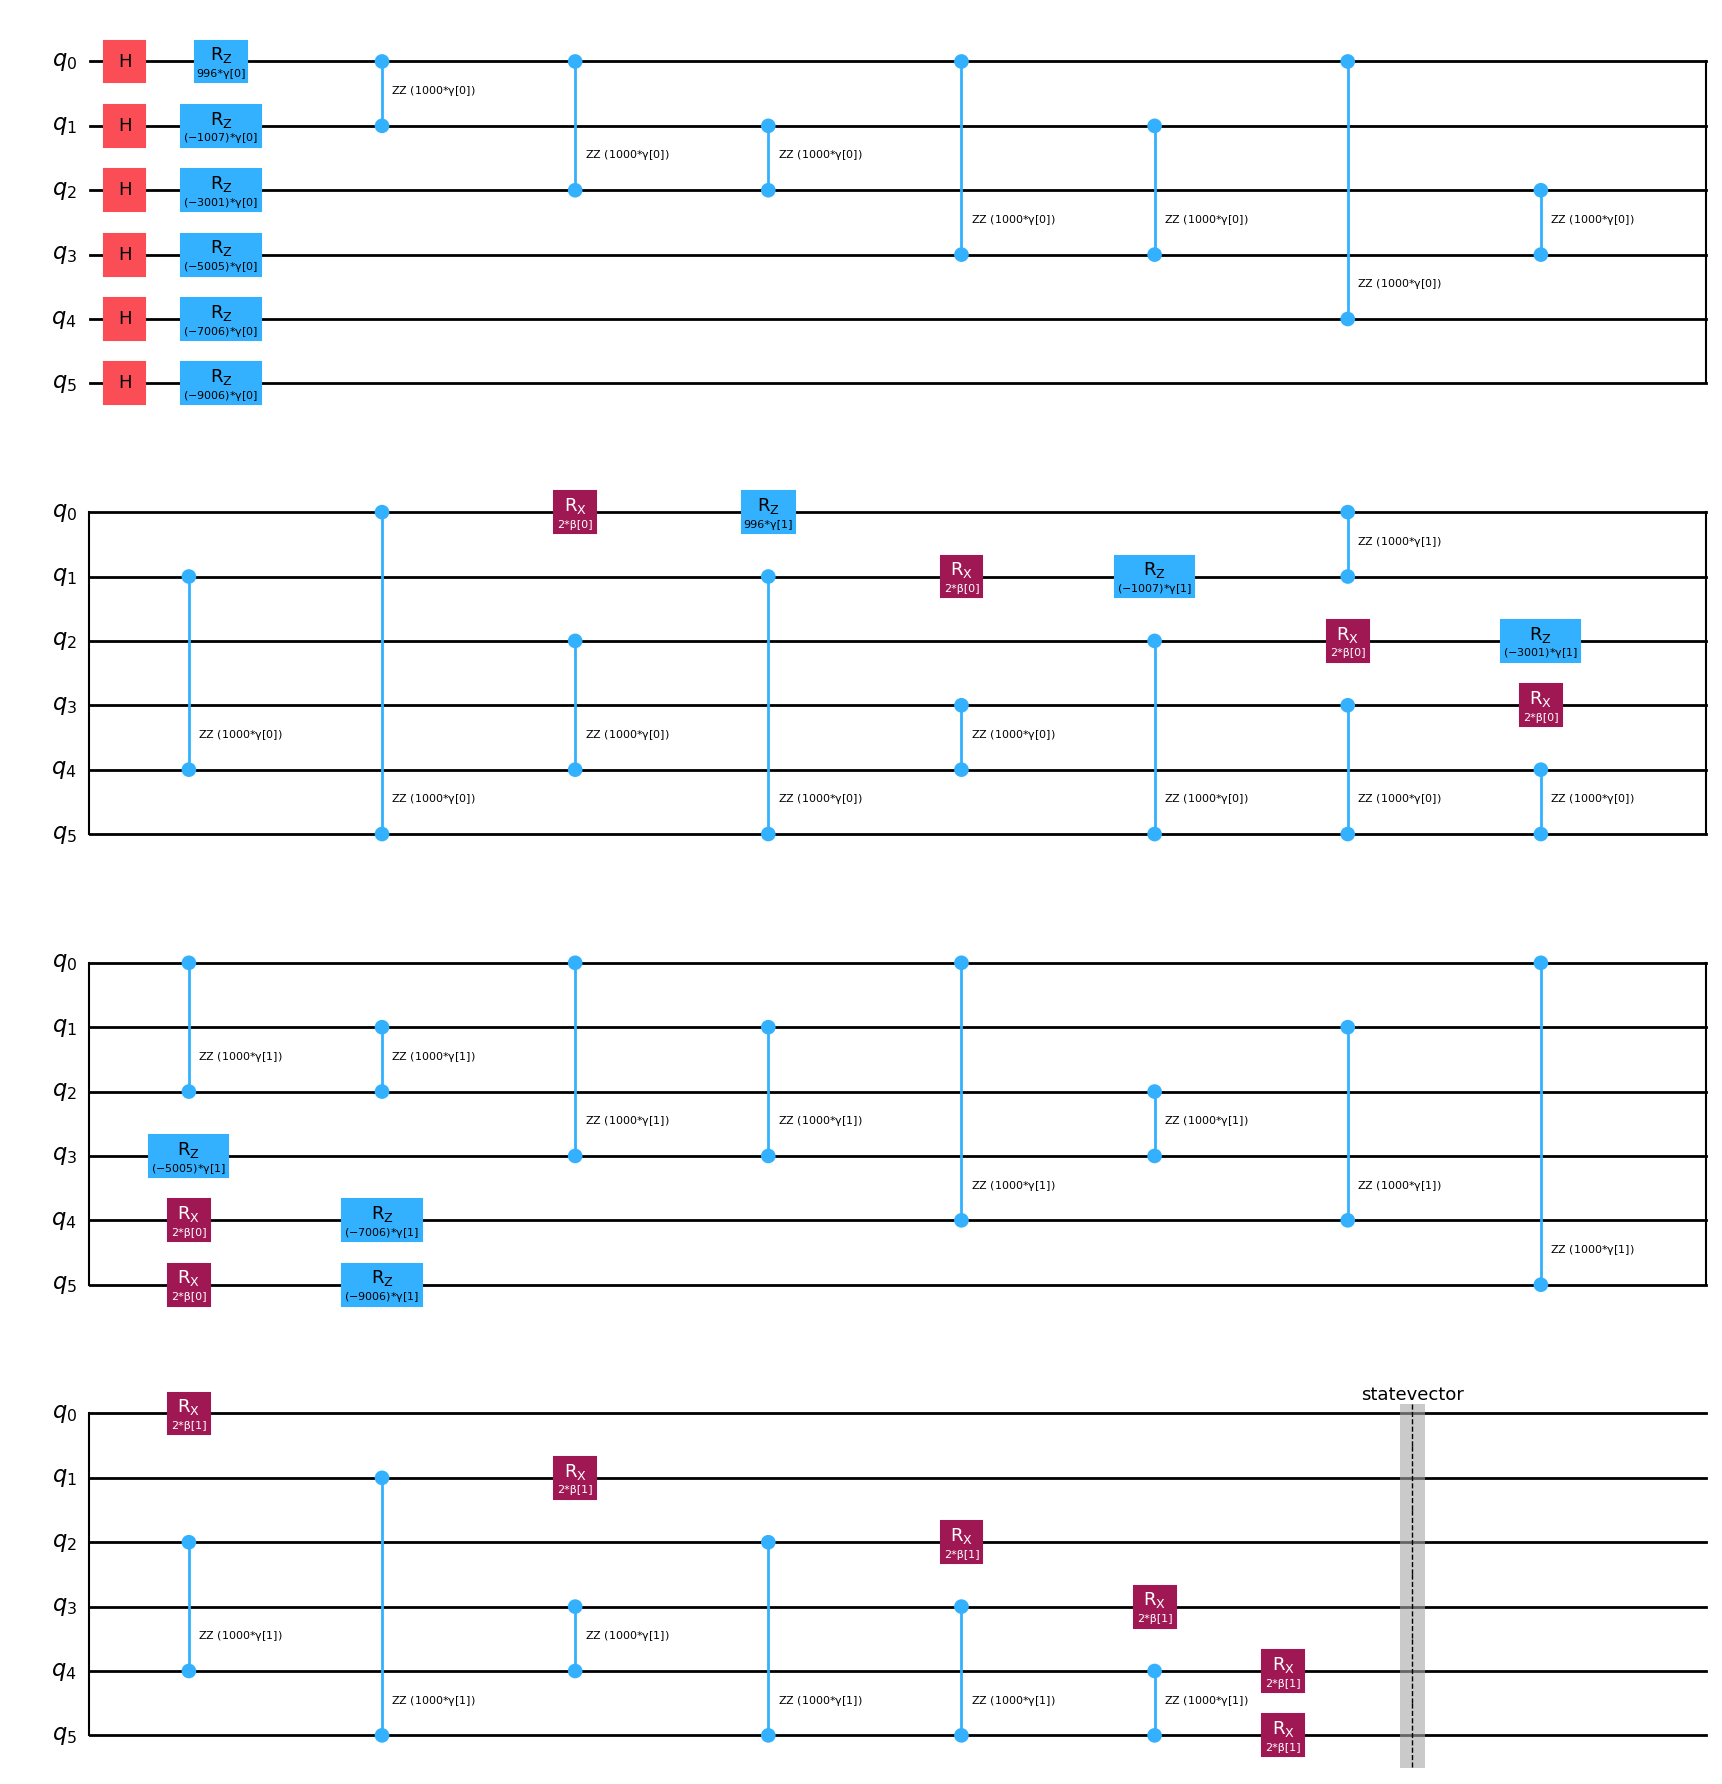

In [604]:
simulator = AerSimulator(method="statevector")
Aer_transpiled_ckt = transpile(circuit, simulator)

Aer_transpiled_ckt.save_statevector()

Aer_transpiled_ckt.draw("mpl")

### State vector simulation (checking for initial parameters)

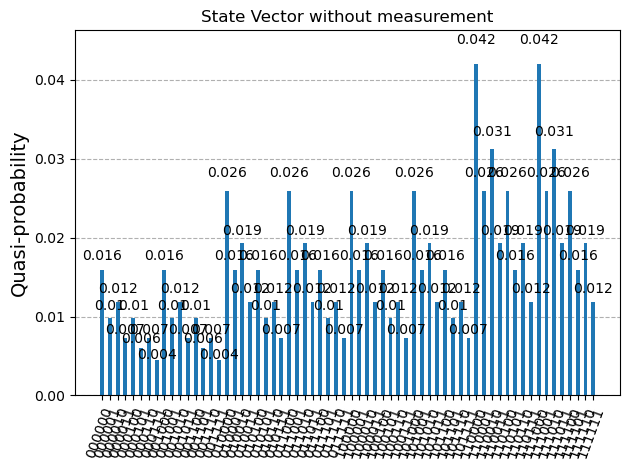

In [605]:
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(binding_dict)

results = simulator.run(bound_Aer_transpiled_ckt).result()
counts = results.get_counts()
plot_histogram(counts, title="State Vector without measurement")

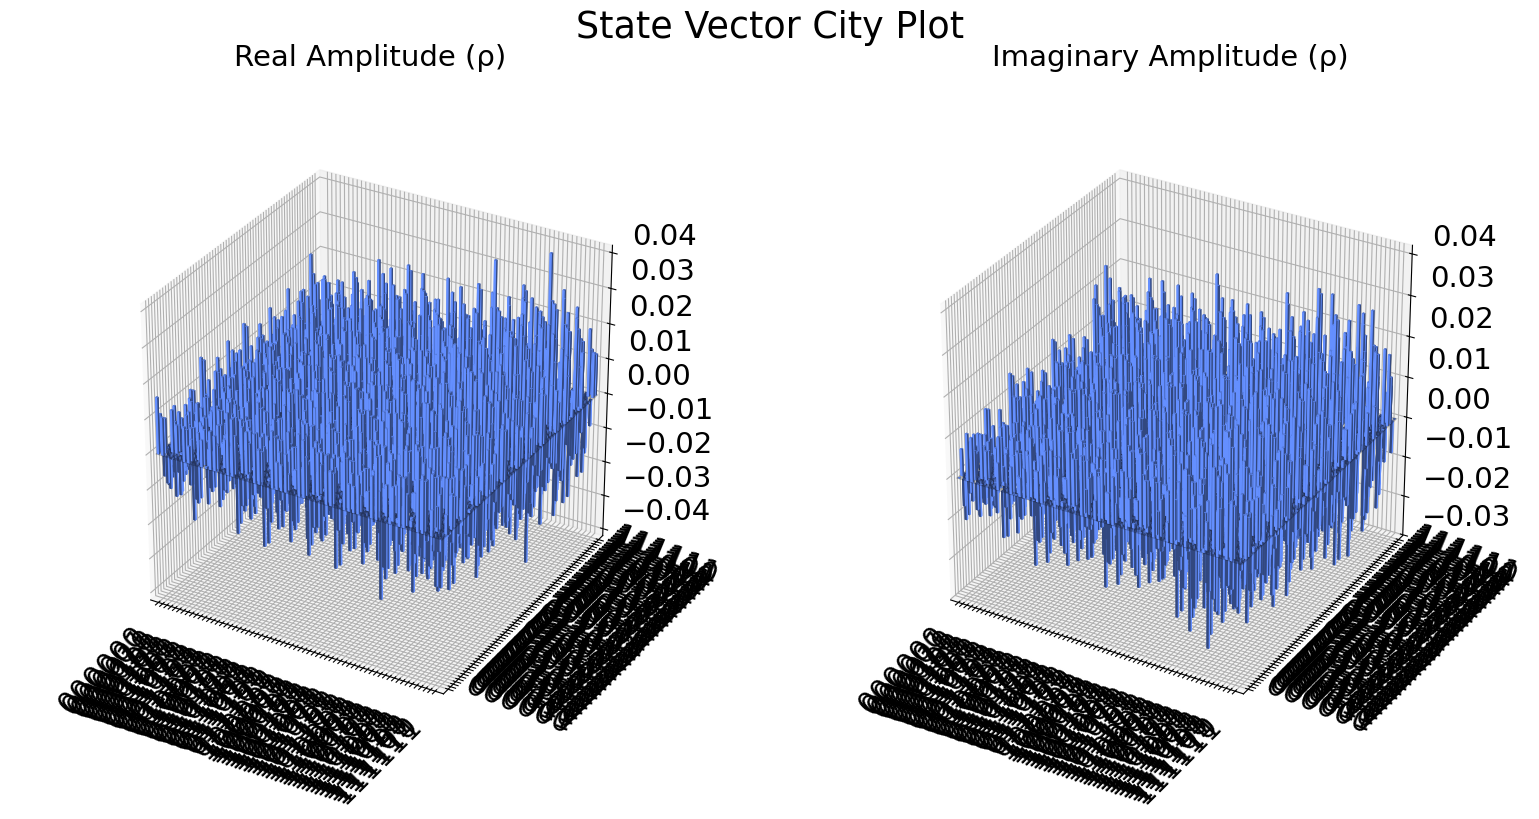

In [606]:
state_vector = results.get_statevector()

plot_state_city(state_vector, title="State Vector City Plot")

## Optimization

### Estimator for evaluating Energy or Cost



In [607]:
obj_fn_costs_iter = []

In [608]:
def Average_Energy(parameter_values, transpiled_circuit, Cost_hamiltonian, estimator):
    # Bind the parameters to the circuit
    binding_dict = {param: value for param, value in zip(transpiled_circuit.parameters, parameter_values)}
    bound_circuit = transpiled_circuit.assign_parameters(binding_dict)

    #isa_hamiltonian = Cost_hamiltonian.apply_layout(bound_circuit.layout)
    isa_hamiltonian = Cost_hamiltonian.apply_layout(transpiled_circuit.layout)

    #display(bound_circuit.draw("mpl"))

    # Simulate the circuit to get the state vector
    #simulator = AerSimulator(method='statevector')
    #transpiled_ckt = transpile(bound_circuit, simulator)

    #print(Cost_hamiltonian)
    #print(isa_hamiltonian)
    
    #print(transpiled_circuit.parameters)
    #print(len(transpiled_circuit.parameters))

    #print(bound_circuit.parameters)
    #print(len(bound_circuit.parameters))

    pub = (transpiled_circuit, isa_hamiltonian, parameter_values)
    #pub = (bound_circuit, isa_hamiltonian, parameter_values)
    results = estimator.run([pub]).result()

    #print(results[0].data.evs)

    #state_vector = results[0].get_statevector()


    # Compute the expectation value of the cost Hamiltonian
    #stateVect = np.array(state_vector)
    #cost_Mx = np.array(Cost_hamiltonian.to_matrix())
    #energy = np.real(stateVect.conj().T @ cost_Mx @ stateVect)

    #print("Expected Values:", results[0].data.evs)
    #print("Energy:", energy)

    obj_fn_costs_iter.append(results[0].data.evs)

    return results[0].data.evs # energy

In [609]:
obj_fn_costs_iter = []

estimator = Estimator(mode=simulator)
estimator.options.default_shots = 100000
#init_param_values = [0.5, 0.8, 1, 1.2] # [np.pi / 2, np.pi / 2, np.pi / 2, np.pi / 2]

energy = Average_Energy(init_param_values, Aer_transpiled_ckt, Cost_hamiltonian, estimator)

print('Energy:', energy)
print('State vector:', state_vector)

Energy: 1536.030364696353
State vector: Statevector([-0.1246034 -0.02064186j, -0.07478906-0.06503969j,
              0.04468347+0.09933745j, -0.01098904+0.08476806j,
              0.09176721-0.0374479j ,  0.07673286+0.0127116j ,
             -0.07071705-0.04801544j, -0.02751683-0.06117366j,
              0.1246034 +0.02064186j,  0.07478906+0.06503969j,
             -0.04468347-0.09933745j,  0.01098904-0.08476806j,
             -0.09176721+0.0374479j , -0.07673286-0.0127116j ,
              0.07071705+0.04801544j,  0.02751683+0.06117366j,
             -0.14901707+0.06081014j, -0.1246034 -0.02064186j,
              0.11483456+0.07797034j,  0.04468347+0.09933745j,
              0.07458642-0.10192624j,  0.09176721-0.0374479j ,
             -0.10881489-0.00488482j, -0.07071705-0.04801544j,
              0.14901707-0.06081014j,  0.1246034 +0.02064186j,
             -0.11483456-0.07797034j, -0.04468347-0.09933745j,
             -0.07458642+0.10192624j, -0.09176721+0.0374479j ,
              0

### Classical parameter optimization through minimize function


Optimal parameters: [2.09467475 1.90416806 0.65044376 3.74650841]
Minimum energy: -6117.607748922511


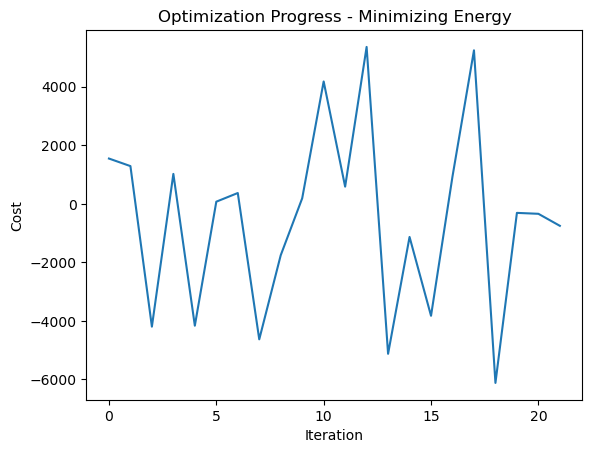

In [610]:
obj_fn_costs_iter = []

result = minimize(
        Average_Energy,
        init_param_values,
        args=(Aer_transpiled_ckt, Cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
)

optimal_parameters = result.x

print("Optimal parameters:", result.x)
print("Minimum energy:", result.fun)

plt.plot(obj_fn_costs_iter)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Optimization Progress - Minimizing Energy")
plt.show()

## Results


### Generate Sampler output of the circuit assigned with best parameters


{'000001': 66, '000101': 206, '001001': 76, '001111': 18, '000100': 110, '100100': 65, '001100': 18, '000000': 29, '001101': 50, '000111': 35, '100101': 73, '001110': 7, '010101': 56, '011001': 16, '010001': 32, '001011': 14, '100000': 9, '000011': 23, '010111': 9, '010100': 6, '101001': 4, '011101': 21, '010110': 4, '011110': 3, '011100': 4, '010011': 10, '011000': 2, '100110': 3, '111101': 7, '010000': 1, '011011': 1, '110111': 6, '101100': 2, '100001': 3, '001010': 4, '011010': 2, '110101': 4, '111010': 1, '101011': 1, '111110': 1, '011111': 6, '101111': 4, '111011': 1, '000110': 2, '101110': 2, '111100': 1, '110100': 2, '100111': 2, '010010': 1, '100011': 1}


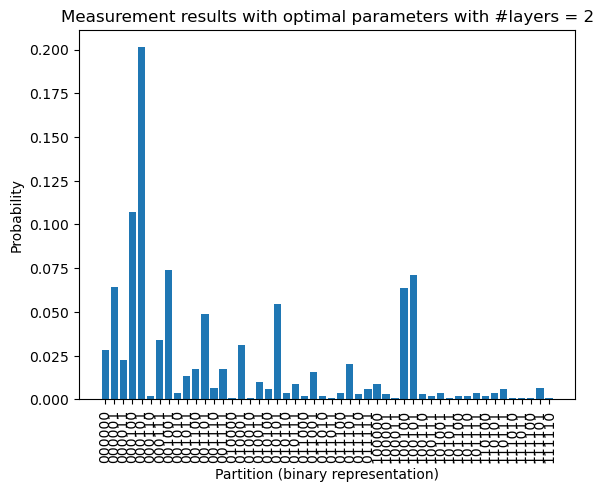

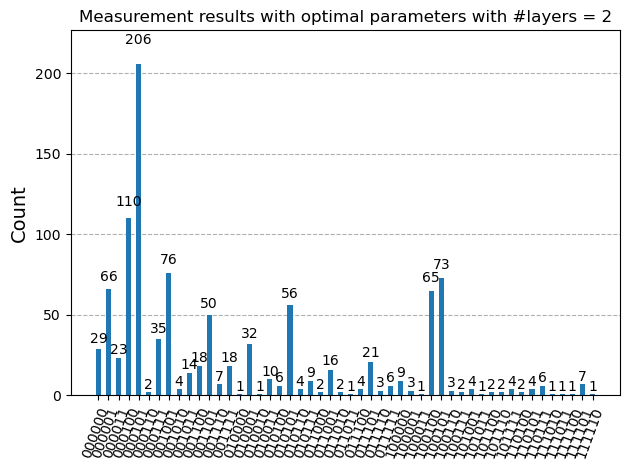

In [611]:
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)
bound_Aer_transpiled_ckt.measure_all()

#display(bound_Aer_transpiled_ckt.draw("mpl"))

sampler = Sampler(mode=simulator)
result = sampler.run([bound_Aer_transpiled_ckt]).result()
#print("result:", result)

print(result[0].data.meas.get_counts())

#print(result[0].data.keys(), result[0].data.values(), result[0].data.ndim, result[0].data.shape, result[0].data.size)


bit_strings, frequencies = zip(*sorted(zip(result[0].data.meas.get_counts().keys(), list(result[0].data.meas.get_counts().values()))))
Probabilites = [frequencies[i]/sum(frequencies) for i in range(len(frequencies))]
plt.bar(bit_strings, Probabilites)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Probability')
plt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))
plt.xticks(rotation=90)
plt.show()

plot_histogram(result[0].data.meas.get_counts(), title="Measurement results with optimal parameters with #layers = " + str(p_reps))


### Optimal Scheduling


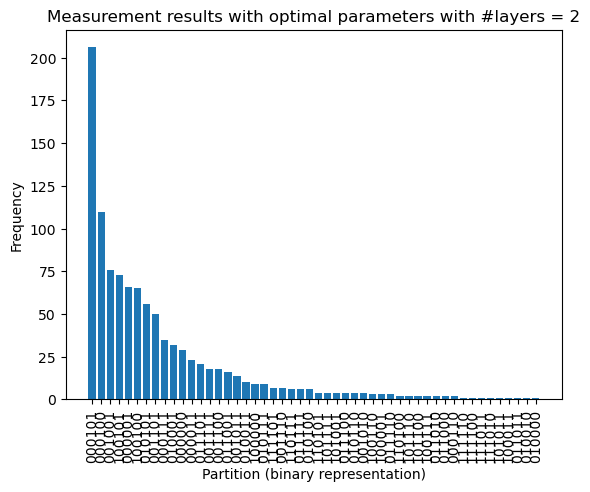

In [612]:
frequencies, bit_strings = zip(*sorted(zip(result[0].data.meas.get_counts().values(), list(result[0].data.meas.get_counts().keys())), reverse=True))
plt.bar(bit_strings, frequencies)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Frequency')
plt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))
plt.xticks(rotation=90)
plt.show()




### Visualization

In [613]:
w

array([[4, 1, 6],
       [7, 5, 6]], dtype=int32)

In [614]:
[int(bit_strings[0][i]) for i in range(len(bit_strings[0]))]

[0, 0, 0, 1, 0, 1]